<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/Skin_Cancer_Classification_Using_EfficientNetB3_on_the_HAM10000_Dataset%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
base_path = "/content/drive/MyDrive/Skin Cancer MNIST HAM10000"

split_path = os.path.join(base_path, "split")
train_path = os.path.join(split_path, "train")
test_path  = os.path.join(split_path, "test")

In [ ]:
IMG_SIZE = 300
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [ ]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(input_layer, output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,706,678 (44.66 MB)

 Trainable params: 4,475,777 (17.07 MB)

 Non-trainable params: 7,230,901 (27.58 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("ham10000_best.h5", save_best_only=True)
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.2941 - loss: 2.3870 

251/251 ━━━━━━━━━━━━━━━━━━━━ 5754s 23s/step - accuracy: 0.3985 - loss: 2.0558 - val_accuracy: 0.6455 - val_loss: 1.2944 - learning_rate: 1.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5903 - loss: 1.5077 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3892s 16s/step - accuracy: 0.6194 - loss: 1.4055 - val_accuracy: 0.7439 - val_loss: 0.9162 - learning_rate: 1.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.6619 - loss: 1.2284 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3874s 15s/step - accuracy: 0.6775 - loss: 1.1762 - val_accuracy: 0.7544 - val_loss: 0.8238 - learning_rate: 1.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7105 - loss: 1.0239 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3850s 15s/step - accuracy: 0.7184 - loss: 1.0125 - val_accuracy: 0.7624 - val_loss: 0.7980 - learning_rate: 1.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7297 - loss: 0.9376 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3882s 15s/step - accuracy: 0.7356 - loss: 0.9218 - val_accuracy: 0.7564 - val_loss: 0.7768 - learning_rate: 1.0000e-04
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7508 - loss: 0.8548 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3859s 15s/step - accuracy: 0.7458 - loss: 0.8742 - val_accuracy: 0.7703 - val_loss: 0.7437 - learning_rate: 1.0000e-04
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7529 - loss: 0.8068 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3864s 15s/step - accuracy: 0.7586 - loss: 0.8035 - val_accuracy: 0.7838 - val_loss: 0.6777 - learning_rate: 1.0000e-04
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 3906s 16s/step - accuracy: 0.7707 - loss: 0.7458 - val_accuracy: 0.7763 - val_loss: 0.7217 - learning_rate: 1.0000e-04
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7761 - loss: 0.7192 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3873s 15s/step - accuracy: 0.7810 - loss: 0.7010 - val_accuracy: 0.7863 - val_loss: 0.6753 - learning_rate: 1.0000e-04
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7716 - loss: 0.7241 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3900s 16s/step - accuracy: 0.7795 - loss: 0.6985 - val_accuracy: 0.7878 - val_loss: 0.6691 - learning_rate: 1.0000e-04


In [ ]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Final Loss:", loss)
print("Final Accuracy: {:.2f}%".format(acc * 100))
print("="*40)

63/63 ━━━━━━━━━━━━━━━━━━━━ 665s 10s/step - accuracy: 0.7878 - loss: 0.6691
Final Loss: 0.6690963506698608
Final Accuracy: 78.78%


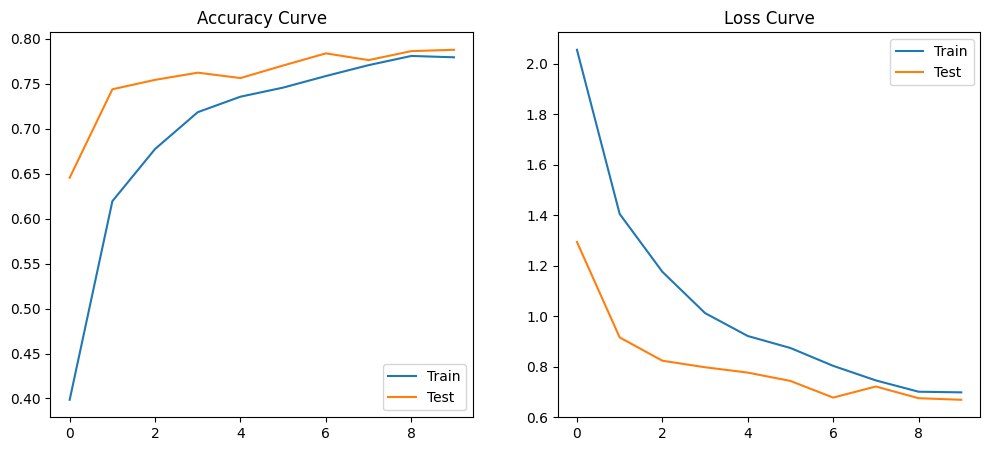

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.legend(['Train','Test'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(['Train','Test'])

plt.show()

In [ ]:
# Get true labels
y_true = test_generator.classes

# Get prediction probabilities
y_pred_prob = model.predict(test_generator)

# Number of classes
n_classes = train_generator.num_classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 676s 11s/step


63/63 ━━━━━━━━━━━━━━━━━━━━ 662s 10s/step


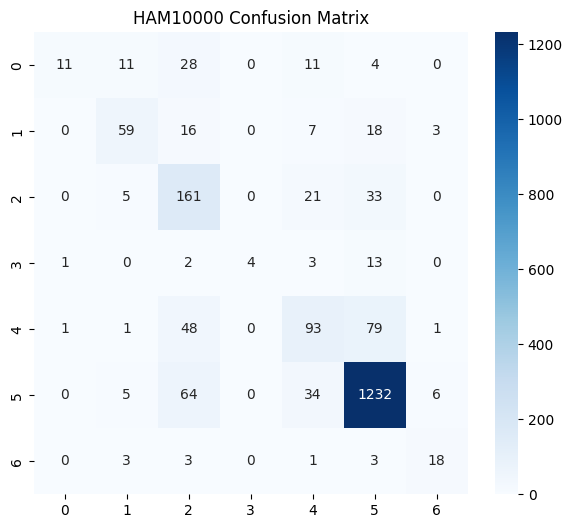

In [ ]:
y_pred = np.argmax(model.predict(test_generator), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("HAM10000 Confusion Matrix")
plt.show()

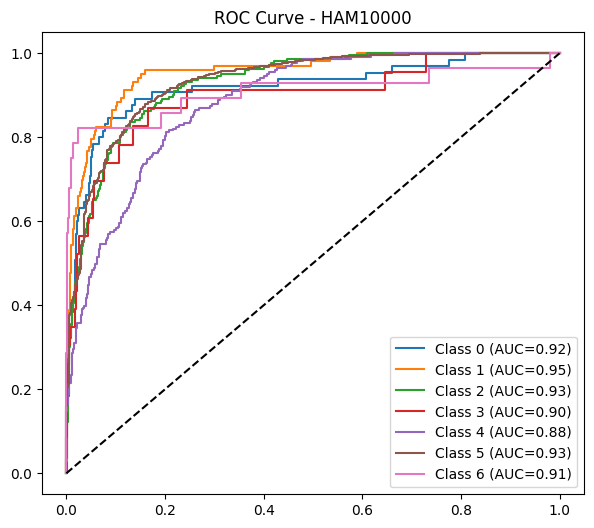

In [ ]:
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))


plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc_score:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - HAM10000")
plt.legend()
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

              precision    recall  f1-score   support

       akiec       0.85      0.17      0.28        65
         bcc       0.70      0.57      0.63       103
         bkl       0.50      0.73      0.59       220
          df       1.00      0.17      0.30        23
         mel       0.55      0.42      0.47       223
          nv       0.89      0.92      0.90      1341
        vasc       0.64      0.64      0.64        28

    accuracy                           0.79      2003
   macro avg       0.73      0.52      0.55      2003
weighted avg       0.80      0.79      0.78      2003



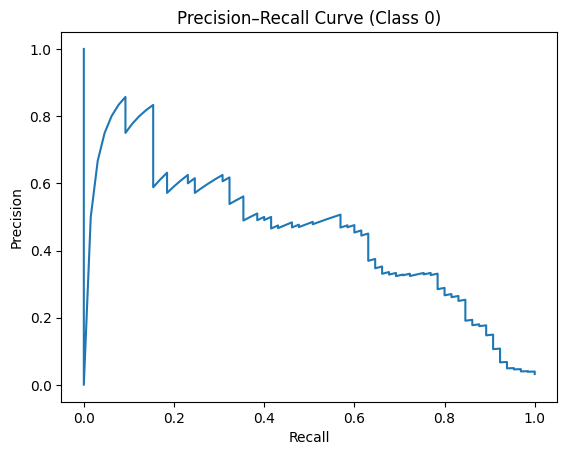

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

class_index = 0  # change to 1,2,3... if needed

precision, recall, _ = precision_recall_curve(
    y_true == class_index,
    y_pred_prob[:, class_index]
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (Class {class_index})")
plt.show()

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.7777512549993786
